In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install wandb -q

import numpy as np
import random
import time
import os
import json

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import wandb
from wandb.integration.keras import WandbMetricsLogger

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from google.colab import userdata


In [3]:
wandb_api_key = userdata.get('WANDB_API_KEY_1')
wandb.login(key=wandb_api_key)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akeke23 (akeke23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
SEED = 42
def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_all_seeds()
print(f"✅ Seed დაფიქსირდა: {SEED}")

✅ Seed დაფიქსირდა: 42


In [7]:

data = np.load('/content/drive/MyDrive/Ketastasia/data/dataset_seq15_ready.npz')

X_train = data['X_train']
y_train_text = data['y_train']
X_val   = data['X_val']
y_val_text   = data['y_val']

le = LabelEncoder()
y_train_idx = le.fit_transform(y_train_text)
y_val_idx   = le.transform(y_val_text)


classes = list(le.classes_)
n_classes = len(classes)
n_timesteps = X_train.shape[1]   # 15 კადრი
n_features  = X_train.shape[2]   # 29 ფიჩერი

y_train = keras.utils.to_categorical(y_train_idx, num_classes=n_classes)
y_val   = keras.utils.to_categorical(y_val_idx, num_classes=n_classes)


print("=== 🎉 მონაცემები სრულად მომზადდა! ===")
print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape},   y={y_val.shape}")
print(f"კლასების რაოდენობა: {n_classes} -> {classes}")

# Class weights - ისევე გვჭირდება, დატა კვლავ დაუბალანსებელია
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(n_classes),
    y=y_train_idx
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}

=== 🎉 მონაცემები სრულად მომზადდა! ===
Train: X=(2940, 15, 29), y=(2940, 25)
Val:   X=(580, 15, 29),   y=(580, 25)
კლასების რაოდენობა: 25 -> [np.str_('bench_press'), np.str_('bicep_curl'), np.str_('chest_fly'), np.str_('clean_and_jerk'), np.str_('deadlift'), np.str_('decline_bench_press'), np.str_('hammer_curl'), np.str_('hip_thrust'), np.str_('incline_bench_press'), np.str_('jump_rope'), np.str_('lat_pulldown'), np.str_('lateral_raise'), np.str_('leg_extension'), np.str_('leg_raises'), np.str_('plank'), np.str_('pullup'), np.str_('pushup'), np.str_('romanian_deadlift'), np.str_('russian_twist'), np.str_('shoulder_press'), np.str_('situp'), np.str_('squat'), np.str_('t_bar_row'), np.str_('tricep_dips'), np.str_('tricep_pushdown')]


In [8]:

def build_bilstm(hidden=64, n_layers=1, dropout_rate=0.0, lr=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_timesteps, n_features)))

    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        model.add(layers.Bidirectional(
            layers.LSTM(
                hidden,
                return_sequences=return_seq,
                dropout=dropout_rate,
                recurrent_dropout=dropout_rate
            )
        ))

    model.add(layers.Dense(64, activation='relu'))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [9]:

configs = [
    {'hidden': 32,  'n_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'hidden': 64,  'n_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'hidden': 64,  'n_layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'hidden': 32,  'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'hidden': 64,  'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'hidden': 64,  'n_layers': 2, 'dropout': 0.4, 'lr': 0.0005, 'batch_size': 64, 'epochs': 40},
    {'hidden': 128, 'n_layers': 2, 'dropout': 0.4, 'lr': 0.0005, 'batch_size': 64, 'epochs': 40},
]
print(f"მომზადებულია {len(configs)} BiLSTM ექსპერიმენტი გასაშვებად! 🚀")


მომზადებულია 7 BiLSTM ექსპერიმენტი გასაშვებად! 🚀


In [10]:

def run_single_experiment(cfg, use_class_weights, run_tag):
    run_name = (
        f"bilstm-h{cfg['hidden']}-l{cfg['n_layers']}-d{cfg['dropout']}"
        f"-lr{cfg['lr']}-bs{cfg['batch_size']}-{run_tag}"
    )
    print(f"\n{'-'*60}\n🚀 იწყება: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p1_bilstm',
        name=run_name,
        config={
            **cfg,
            'architecture': 'BiLSTM',
            'class_weights_included': use_class_weights,
            'n_timesteps': n_timesteps,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline1A_13kp',
            'normalization': 'per_frame_hip_centered',
            'seed': SEED,
        },
        reinit=True
    )

    model = build_bilstm(
        hidden=cfg['hidden'],
        n_layers=cfg['n_layers'],
        dropout_rate=cfg['dropout'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=4, verbose=1
        )
    ]

    fit_kwargs = dict(
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )
    if use_class_weights:
        fit_kwargs['class_weight'] = class_weight_dict

    # --- ვზომავთ ტრენინგის დროს ---
    t0 = time.time()
    model.fit(X_train, y_train, **fit_kwargs)
    training_time_sec = time.time() - t0

    # --- შეფასება Train-ზეც (overfitting gap-ისთვის) და Val-ზე ---
    y_pred_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
    y_true_train = np.argmax(y_train, axis=1)
    report_train = classification_report(
        y_true_train, y_pred_train,
        labels=list(range(n_classes)), target_names=classes,
        output_dict=True, zero_division=0
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)
    y_true_val = np.argmax(y_val, axis=1)
    report_val = classification_report(
        y_true_val, y_pred_val,
        labels=list(range(n_classes)), target_names=classes,
        output_dict=True, zero_division=0
    )

    val_f1_macro = report_val['macro avg']['f1-score']
    train_f1_macro = report_train['macro avg']['f1-score']
    overfit_gap = train_f1_macro - val_f1_macro

    # --- Inference speed: ერთი sequence-ის დამუშავების საშუალო დრო ---
    n_speed_samples = min(200, len(X_val))
    warmup = model.predict(X_val[:8], verbose=0)  # warm-up, პირველი გამოძახება ყოველთვის ნელია
    t0 = time.time()
    _ = model.predict(X_val[:n_speed_samples], verbose=0)
    inference_ms_per_seq = ((time.time() - t0) / n_speed_samples) * 1000

    # --- Confusion matrix ---
    cm_val = confusion_matrix(y_true_val, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix — {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_train_f1_macro':     train_f1_macro,
        'final_val_accuracy':       val_acc,
        'final_val_loss':           val_loss,
        'val_f1_macro':             val_f1_macro,
        'val_f1_weighted':          report_val['weighted avg']['f1-score'],
        'overfit_gap_f1':           overfit_gap,
        'training_time_sec':        training_time_sec,
        'inference_ms_per_seq':     inference_ms_per_seq,
        'val_confusion_matrix_db':  wandb.plot.confusion_matrix(
            probs=None, y_true=y_true_val.tolist(), preds=y_pred_val.tolist(),
            class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path),
    })

    os.makedirs('/content/drive/MyDrive/Ketastasia/models', exist_ok=True)
    model_path = f'/content/drive/MyDrive/Ketastasia/models/{run_name}.h5'
    model.save(model_path)

    n_params = model.count_params()

    wandb.finish()

    print(f"✨ {run_name} → val_f1_macro={val_f1_macro:.4f}, "
          f"overfit_gap={overfit_gap:.4f}, params={n_params}")

    # ეს dict ინახება ცენტრალურ შედეგების ცხრილში (Cell 7-ში)
    return {
        'run_name': run_name,
        'model_path': model_path,
        'hidden': cfg['hidden'],
        'n_layers': cfg['n_layers'],
        'dropout': cfg['dropout'],
        'lr': cfg['lr'],
        'batch_size': cfg['batch_size'],
        'class_weights': use_class_weights,
        'n_params': n_params,
        'val_f1_macro': val_f1_macro,
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_accuracy': val_acc,
        'train_f1_macro': train_f1_macro,
        'overfit_gap_f1': overfit_gap,
        'training_time_sec': training_time_sec,
        'inference_ms_per_seq': inference_ms_per_seq,
    }



In [11]:

all_results = []

for cfg in configs:
    # ვარიანტი A: მხოლოდ dropout, class weights-ის გარეშე
    res = run_single_experiment(cfg, use_class_weights=False, run_tag='plain')
    all_results.append(res)

    # ვარიანტი B: dropout + class weights ერთად
    res_cw = run_single_experiment(cfg, use_class_weights=True, run_tag='cw')
    all_results.append(res_cw)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('val_f1_macro', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("📊 ყველა BiLSTM ექსპერიმენტის შედარება (დალაგებული val_f1_macro-ით):")
print("="*80)
print(results_df[['run_name', 'n_params', 'val_f1_macro', 'val_accuracy',
                   'overfit_gap_f1', 'training_time_sec', 'inference_ms_per_seq']]
      .to_string(index=False))

# შედეგების ცხრილის შენახვა - ეს არის თქვენი "მტკიცებულება" საბოლოო
# რეპორტისთვის, თუ რატომ აირჩიეთ კონკრეტული მოდელი
results_csv_path = '/content/drive/MyDrive/Ketastasia/models/bilstm_all_results.csv'
results_df.to_csv(results_csv_path, index=False)
print(f"\n💾 შედეგების ცხრილი შენახულია: {results_csv_path}")


------------------------------------------------------------
🚀 იწყება: bilstm-h32-l1-d0.0-lr0.001-bs32-plain
------------------------------------------------------------


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2320 - loss: 2.7443 - val_accuracy: 0.2534 - val_loss: 2.5845 - learning_rate: 0.0010
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3517 - loss: 2.2096 - val_accuracy: 0.2638 - val_loss: 2.4820 - learning_rate: 0.0010
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3895 - loss: 2.0111 - val_accuracy: 0.2879 - val_loss: 2.4453 - learning_rate: 0.0010
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4136 - loss: 1.8920 - val_accuracy: 0.2948 - val_loss: 2.4074 - learning_rate: 0.0010
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4282 - loss: 1.8112 - val_accuracy: 0.3121 - val_loss: 2.3673 - learning_rate: 0.0010
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4446 - loss: 1.7450 - val_accuracy: 0.3241 - val_loss: 2.3492 - learning_rate: 0.0010
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4605 - loss: 1.6853 - val_acc

epoch/accuracy,▁▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇████████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,████████████▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▃▃▄▅▅▅▆▆▆▆▇▆▆▇▇▇▇▇████████████████████
epoch/val_loss,█▅▄▃▂▁▁▁▁▂▂▃▃▃▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄
final_train_f1_macro,▁
final_val_accuracy,▁
final_val_loss,▁
inference_ms_per_seq,▁
+4,...


✨ bilstm-h32-l1-d0.0-lr0.001-bs32-plain → val_f1_macro=0.2558, overfit_gap=0.2749, params=21657

------------------------------------------------------------
🚀 იწყება: bilstm-h32-l1-d0.0-lr0.001-bs32-cw
------------------------------------------------------------


...

epoch/accuracy,▁▃▃▄▄▄▄▄▅▅▆▅▅▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇████
epoch/epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁
epoch/val_accuracy,▁▂▂▃▂▂▃▃▄▃▄▄▆▅▆▆▅▆▆▇▆▆▇█▆▆▆▇▆▆▇▇
epoch/val_loss,█▇▆▆▅▅▅▄▄▄▄▄▃▄▃▃▃▃▃▂▂▂▃▂▂▂▂▁▂▁▁▁
final_train_f1_macro,▁
final_val_accuracy,▁
final_val_loss,▁
inference_ms_per_seq,▁
+4,...


✨ bilstm-h128-l2-d0.4-lr0.0005-bs64-plain → val_f1_macro=0.1731, overfit_gap=0.1152, params=574105

------------------------------------------------------------
🚀 იწყება: bilstm-h128-l2-d0.4-lr0.0005-bs64-cw
------------------------------------------------------------


Epoch 1/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 316ms/step - accuracy: 0.0755 - loss: 3.1423 - val_accuracy: 0.1052 - val_loss: 2.9693 - learning_rate: 5.0000e-04
Epoch 2/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 262ms/step - accuracy: 0.1173 - loss: 2.9819 - val_accuracy: 0.1379 - val_loss: 2.7486 - learning_rate: 5.0000e-04
Epoch 3/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step - accuracy: 0.1435 - loss: 2.8710 - val_accuracy: 0.1534 - val_loss: 2.7248 - learning_rate: 5.0000e-04
Epoch 4/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 274ms/step - accuracy: 0.1599 - loss: 2.8385 - val_accuracy: 0.1845 - val_loss: 2.6622 - learning_rate: 5.0000e-04
Epoch 5/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 217ms/step - accuracy: 0.1796 - loss: 2.7747 - val_accuracy: 0.1759 - val_loss: 2.6645 - learning_rate: 5.0000e-04
Epoch 6/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 264ms/step - accuracy: 0.1789 - loss: 2.7485 - val_accuracy: 0.2431 - val_loss: 2.6067 - learning_rate: 5.0000e-04
Epoch 7/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 237ms/step - acc

epoch/accuracy,▁▃▄▄▅▅▅▆▆▇▇▇▇▇▇▇████
epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/learning_rate,██████████▃▃▃▃▃▃▃▁▁▁
epoch/loss,█▆▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁
epoch/val_accuracy,▁▂▃▅▄▇▇▇▆▅▅█▆▇▇▇▆▇▇▇
epoch/val_loss,█▄▄▂▃▁▂▂▂▂▂▂▁▂▂▂▁▁▁▁
final_train_f1_macro,▁
final_val_accuracy,▁
final_val_loss,▁
inference_ms_per_seq,▁
+4,...


✨ bilstm-h128-l2-d0.4-lr0.0005-bs64-cw → val_f1_macro=0.1663, overfit_gap=0.0751, params=574105

📊 ყველა BiLSTM ექსპერიმენტის შედარება (დალაგებული val_f1_macro-ით):
                               run_name  n_params  val_f1_macro  val_accuracy  overfit_gap_f1  training_time_sec  inference_ms_per_seq
  bilstm-h64-l1-d0.0-lr0.001-bs32-plain     58009      0.256425      0.401724        0.276142          54.192354              0.819776
  bilstm-h32-l1-d0.0-lr0.001-bs32-plain     21657      0.255780      0.391379        0.274874          64.792105              0.555624
  bilstm-h64-l2-d0.0-lr0.001-bs32-plain    156825      0.254727      0.394828        0.394202         117.259561              1.138738
     bilstm-h64-l2-d0.0-lr0.001-bs32-cw    156825      0.250341      0.341379        0.241727          97.151033              1.125975
     bilstm-h64-l1-d0.0-lr0.001-bs32-cw     58009      0.248530      0.367241        0.351831          74.243777              0.585506
  bilstm-h64-l1-d0.3-lr0.

In [12]:

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("📊 ᲪᲮᲠᲘᲚᲘ #1 — F1-macro-ს მიხედვით (მთავარი კრიტერიუმი):")
print(results_df[['run_name', 'n_params', 'val_f1_macro', 'val_accuracy',
                   'overfit_gap_f1']].sort_values('val_f1_macro', ascending=False)
      .head(10).to_string(index=False))

print("\n📊 ᲪᲮᲠᲘᲚᲘ #2 — overfit_gap-ის მიხედვით (სად ვიზეპირეთ ყველაზე ნაკლებად):")
print(results_df[['run_name', 'val_f1_macro', 'train_f1_macro', 'overfit_gap_f1']]
      .sort_values('overfit_gap_f1', ascending=True).head(10).to_string(index=False))

print("\n📊 ᲪᲮᲠᲘᲚᲘ #3 — სისწრაფის მიხედვით (inference ms/sequence):")
print(results_df[['run_name', 'n_params', 'val_f1_macro', 'inference_ms_per_seq',
                   'training_time_sec']].sort_values('inference_ms_per_seq', ascending=True)
      .head(10).to_string(index=False))

# ცხრილი ასევე იტვირთება wandb-ზეც Table-ის სახით, რომ დეშბორდზეც
# ერთად ნახოთ ყველა run გვერდიგვერდ, ცხრილის სახით
summary_run = wandb.init(
    project="ildolcefarniente",
    job_type="results_summary",
    name="bilstm_all_runs_summary",
    group='p1_bilstm'
)
summary_run.log({"bilstm_results_table": wandb.Table(dataframe=results_df)})
summary_run.finish()

📊 ᲪᲮᲠᲘᲚᲘ #1 — F1-macro-ს მიხედვით (მთავარი კრიტერიუმი):
                             run_name  n_params  val_f1_macro  val_accuracy  overfit_gap_f1
bilstm-h64-l1-d0.0-lr0.001-bs32-plain     58009      0.256425      0.401724        0.276142
bilstm-h32-l1-d0.0-lr0.001-bs32-plain     21657      0.255780      0.391379        0.274874
bilstm-h64-l2-d0.0-lr0.001-bs32-plain    156825      0.254727      0.394828        0.394202
   bilstm-h64-l2-d0.0-lr0.001-bs32-cw    156825      0.250341      0.341379        0.241727
   bilstm-h64-l1-d0.0-lr0.001-bs32-cw     58009      0.248530      0.367241        0.351831
bilstm-h64-l1-d0.3-lr0.001-bs32-plain     58009      0.241902      0.372414        0.178727
bilstm-h32-l1-d0.3-lr0.001-bs32-plain     21657      0.208199      0.350000        0.154003
   bilstm-h32-l1-d0.3-lr0.001-bs32-cw     21657      0.187925      0.277586        0.077922
   bilstm-h64-l1-d0.3-lr0.001-bs32-cw     58009      0.179283      0.281034        0.095067
  bilstm-h64-l2-d0.4-lr0

final version

In [6]:
data = np.load('/content/drive/MyDrive/Ketastasia/data/dataset_seq15_ready.npz')

X_train = data['X_train']; y_train_text = data['y_train']
X_val   = data['X_val'];   y_val_text   = data['y_val']


le = LabelEncoder()
y_train_idx = le.fit_transform(y_train_text)
y_val_idx   = le.transform(y_val_text)


classes = list(le.classes_)
n_classes = len(classes)          # 25
n_timesteps = X_train.shape[1]    # 15
n_features  = X_train.shape[2]    # 29

y_train = keras.utils.to_categorical(y_train_idx, num_classes=n_classes)
y_val   = keras.utils.to_categorical(y_val_idx, num_classes=n_classes)


print(f"კლასების რაოდენობა: {n_classes} -> {classes}")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

კლასების რაოდენობა: 25 -> [np.str_('bench_press'), np.str_('bicep_curl'), np.str_('chest_fly'), np.str_('clean_and_jerk'), np.str_('deadlift'), np.str_('decline_bench_press'), np.str_('hammer_curl'), np.str_('hip_thrust'), np.str_('incline_bench_press'), np.str_('jump_rope'), np.str_('lat_pulldown'), np.str_('lateral_raise'), np.str_('leg_extension'), np.str_('leg_raises'), np.str_('plank'), np.str_('pullup'), np.str_('pushup'), np.str_('romanian_deadlift'), np.str_('russian_twist'), np.str_('shoulder_press'), np.str_('situp'), np.str_('squat'), np.str_('t_bar_row'), np.str_('tricep_dips'), np.str_('tricep_pushdown')]
X_train: (2940, 15, 29), X_val: (580, 15, 29)


In [7]:

class MacroF1EarlyStopping(keras.callbacks.Callback):
    def __init__(self, X_val, y_val_idx, patience=15, restore_best_weights=True):
        super().__init__()
        self.X_val = X_val
        self.y_val_idx = y_val_idx
        self.patience = patience
        self.restore_best_weights = restore_best_weights
        self.best_f1 = -1
        self.wait = 0
        self.best_weights = None
        self.best_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        f1 = classification_report(self.y_val_idx, y_pred, output_dict=True,
                                    zero_division=0)['macro avg']['f1-score']
        logs = logs or {}
        logs['val_f1_macro'] = f1   # ეს ჩნდება wandb-ის ლოგშიც (WandbMetricsLogger)

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.best_epoch = epoch
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True
                if self.restore_best_weights and self.best_weights is not None:
                    self.model.set_weights(self.best_weights)
                    print(f"\n⏹ Early stop ეპოქა {epoch}: აღდგენილია წონები ეპოქიდან "
                          f"{self.best_epoch} (საუკეთესო val_f1_macro={self.best_f1:.4f})")


In [8]:

class AttentionPooling(layers.Layer):
    def __init__(self, units=32, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.score_dense = layers.Dense(units, activation='tanh')
        self.score_out = layers.Dense(1)

    def call(self, inputs):
        score = self.score_out(self.score_dense(inputs))     # (batch, timesteps, 1)
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * inputs, axis=1)    # (batch, features)
        return context, weights

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config


In [9]:

def build_final_bilstm(hidden=64, dropout_rate=0.2, l2_reg=0.0007,
                        noise_std=0.01, lr=0.001):
    inp = layers.Input(shape=(n_timesteps, n_features), name='seq_input')

    x = layers.GaussianNoise(noise_std)(inp)   # ტრენინგის დროს ემატება noise, inference-ზე გამორთულია ავტომატურად

    x = layers.Bidirectional(layers.LSTM(
        hidden, return_sequences=True,
        dropout=dropout_rate,
        kernel_regularizer=keras.regularizers.l2(l2_reg),
        recurrent_regularizer=keras.regularizers.l2(l2_reg),
    ))(x)
    x = layers.BatchNormalization()(x)

    context, attn_weights = AttentionPooling(units=32, name='attention_pooling')(x)

    d = layers.Dense(64, activation='relu',
                      kernel_regularizer=keras.regularizers.l2(l2_reg))(context)
    d = layers.Dropout(dropout_rate)(d)
    out = layers.Dense(n_classes, activation='softmax', name='classifier')(d)

    model = keras.Model(inp, out, name='BiLSTM_Attention_Final')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )

    # დამატებითი "debug" მოდელი (იგივე წონები) - მოგვიანებით attention
    # წონების ვიზუალიზაციისთვის, ტრენინგზე გავლენის გარეშე
    debug_model = keras.Model(inp, [out, attn_weights], name='BiLSTM_Attention_Debug')

    return model, debug_model


In [10]:
RUN_NAME = 'bilstm-final-attention-v1'

model, debug_model = build_final_bilstm(
    hidden=64, dropout_rate=0.2, l2_reg=0.0007, noise_std=0.01, lr=0.001
)
model.summary()

wandb.init(
    project='ildolcefarniente',
    group='p1_bilstm_final',
    name=RUN_NAME,
    config={
        'architecture': 'BiLSTM+Attention', 'hidden': 64, 'n_layers': 1,
        'dropout': 0.2, 'l2_reg': 0.0007, 'gaussian_noise_std': 0.01,
        'label_smoothing': 0.05, 'lr': 0.001, 'batch_size': 32,
        'max_epochs': 100, 'patience': 15, 'seed': SEED,
        'n_params': model.count_params(), 'pipeline': 'pipeline1A_13kp',
    },
    reinit=True
)

f1_callback = MacroF1EarlyStopping(X_val, y_val_idx, patience=15, restore_best_weights=True)
callbacks = [
    WandbMetricsLogger(log_freq='epoch'),
    f1_callback,
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1, min_lr=1e-6),
]

t0 = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
training_time_sec = time.time() - t0


Model: "BiLSTM_Attention_Final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ seq_input (InputLayer)          │ (None, 15, 29)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 15, 29)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 15, 128)        │        48,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling               │ [(None, 128), (None,   │         4,161 │
│ (AttentionPooling)              │ 15, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,682 (244.85 KB)

 Trainable params: 62,426 (243.85 KB)

 Non-trainable params: 256 (1.00 KB)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.2374 - loss: 2.9395 - val_accuracy: 0.2414 - val_loss: 3.1379 - val_f1_macro: 0.0925 - learning_rate: 0.0010
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3180 - loss: 2.6253 - val_accuracy: 0.2586 - val_loss: 2.9508 - val_f1_macro: 0.1083 - learning_rate: 0.0010
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3398 - loss: 2.4989 - val_accuracy: 0.2776 - val_loss: 2.7453 - val_f1_macro: 0.1405 - learning_rate: 0.0010
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3582 - loss: 2.4295 - val_accuracy: 0.2776 - val_loss: 2.6004 - val_f1_macro: 0.1386 - learning_rate: 0.0010
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3643 - loss: 2.3728 - val_accuracy: 0.3310 - val_loss: 2.5469 - val_f1_macro: 0.1882 - learning_rate: 0.0010
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3942 - loss: 2.2981 - val_accuracy: 0.3034 - val_loss: 2.5


📊 საბოლოო შედეგები — bilstm-final-attention-v1
Train F1-macro:      0.4839
Val F1-macro:        0.2488   <- მთავარი მეტრიკა
Val F1-weighted:     0.3578
Val Accuracy:        0.3724
Overfit gap (F1):    0.2351   (⚠️ შემოწმდეს)
საუკეთესო ეპოქა:      27
Training time:       171.8 წამი
Inference speed:     0.63 ms/sequence


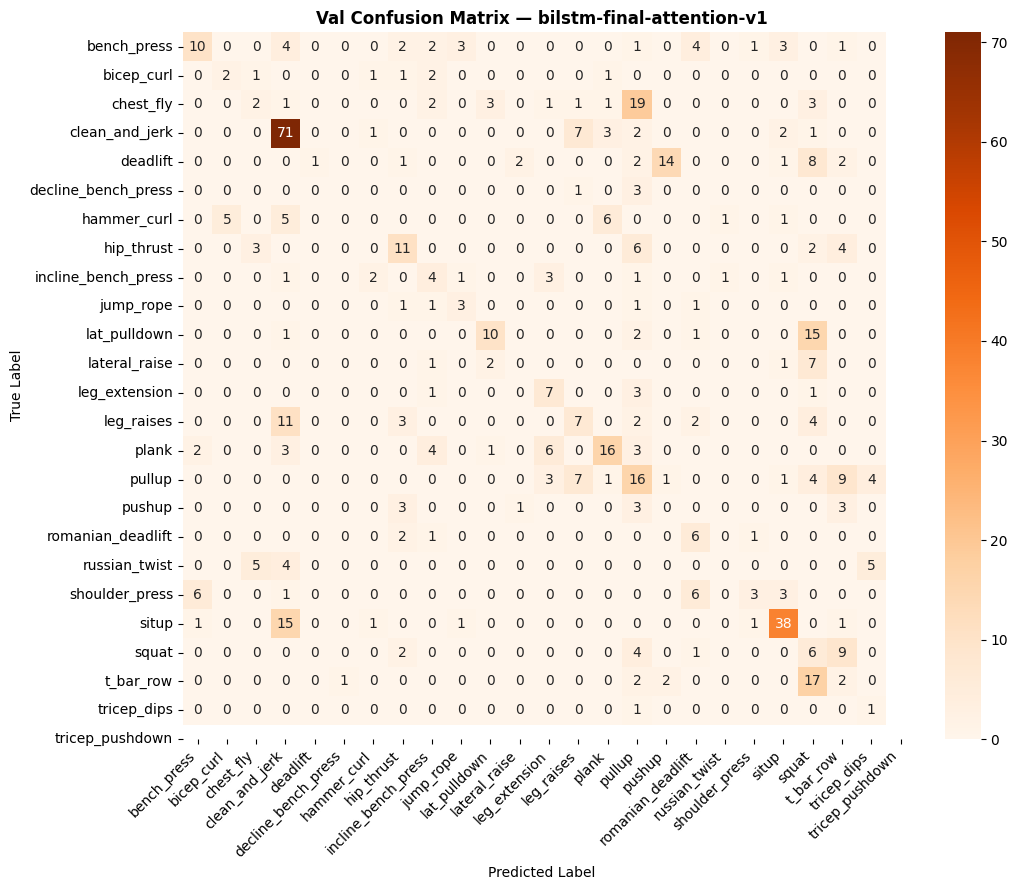


💾 მოდელი შენახულია: /content/drive/MyDrive/Ketastasia/models/bilstm-final-attention-v1.h5


best_epoch,▁
epoch/accuracy,▁▃▃▄▄▄▅▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██▇█████
epoch/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
epoch/learning_rate,██████████████████▄▄▄▄▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁
epoch/loss,█▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▃▃▆▅▆▆▇▇▇██▇█▆▅█▆▆▆▆▇▇█▇▇▇▇▇▇▆▆▇▇▇▇▇▇▇
epoch/val_loss,█▆▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▁▁▂▁▁▁
final_train_f1_macro,▁
final_val_accuracy,▁
final_val_loss,▁
+5,...


In [11]:
y_pred_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
train_f1_macro = classification_report(
    np.argmax(y_train, axis=1), y_pred_train, output_dict=True, zero_division=0
)['macro avg']['f1-score']

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)
y_true_val = np.argmax(y_val, axis=1)
report_val = classification_report(
    y_true_val, y_pred_val, labels=list(range(n_classes)),
    target_names=classes, output_dict=True, zero_division=0
)
val_f1_macro = report_val['macro avg']['f1-score']
val_f1_weighted = report_val['weighted avg']['f1-score']
overfit_gap = train_f1_macro - val_f1_macro

n_speed_samples = min(200, len(X_val))
_ = model.predict(X_val[:8], verbose=0)  # warm-up
t0 = time.time()
_ = model.predict(X_val[:n_speed_samples], verbose=0)
inference_ms_per_seq = ((time.time() - t0) / n_speed_samples) * 1000

print("\n" + "="*70)
print(f"📊 საბოლოო შედეგები — {RUN_NAME}")
print("="*70)
print(f"Train F1-macro:      {train_f1_macro:.4f}")
print(f"Val F1-macro:        {val_f1_macro:.4f}   <- მთავარი მეტრიკა")
print(f"Val F1-weighted:     {val_f1_weighted:.4f}")
print(f"Val Accuracy:        {val_acc:.4f}")
print(f"Overfit gap (F1):    {overfit_gap:.4f}   ({'✅ კარგი' if overfit_gap < 0.10 else '⚠️ შემოწმდეს'})")
print(f"საუკეთესო ეპოქა:      {f1_callback.best_epoch}")
print(f"Training time:       {training_time_sec:.1f} წამი")
print(f"Inference speed:     {inference_ms_per_seq:.2f} ms/sequence")

cm_val = confusion_matrix(y_true_val, y_pred_val)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f'Val Confusion Matrix — {RUN_NAME}', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
cm_path = f'/content/{RUN_NAME}_val_cm.png'
plt.savefig(cm_path, dpi=150)
plt.show()

wandb.log({
    'final_train_f1_macro': train_f1_macro,
    'val_f1_macro': val_f1_macro,
    'val_f1_weighted': val_f1_weighted,
    'final_val_accuracy': val_acc,
    'final_val_loss': val_loss,
    'overfit_gap_f1': overfit_gap,
    'training_time_sec': training_time_sec,
    'inference_ms_per_seq': inference_ms_per_seq,
    'best_epoch': f1_callback.best_epoch,
    'val_confusion_matrix_db': wandb.plot.confusion_matrix(
        probs=None, y_true=y_true_val.tolist(), preds=y_pred_val.tolist(), class_names=classes
    ),
    'val_confusion_matrix_img': wandb.Image(cm_path),
})

os.makedirs('/content/drive/MyDrive/Ketastasia/models', exist_ok=True)
model_path = f'/content/drive/MyDrive/Ketastasia/models/{RUN_NAME}.h5'
model.save(model_path)
print(f"\n💾 მოდელი შენახულია: {model_path}")

wandb.finish()


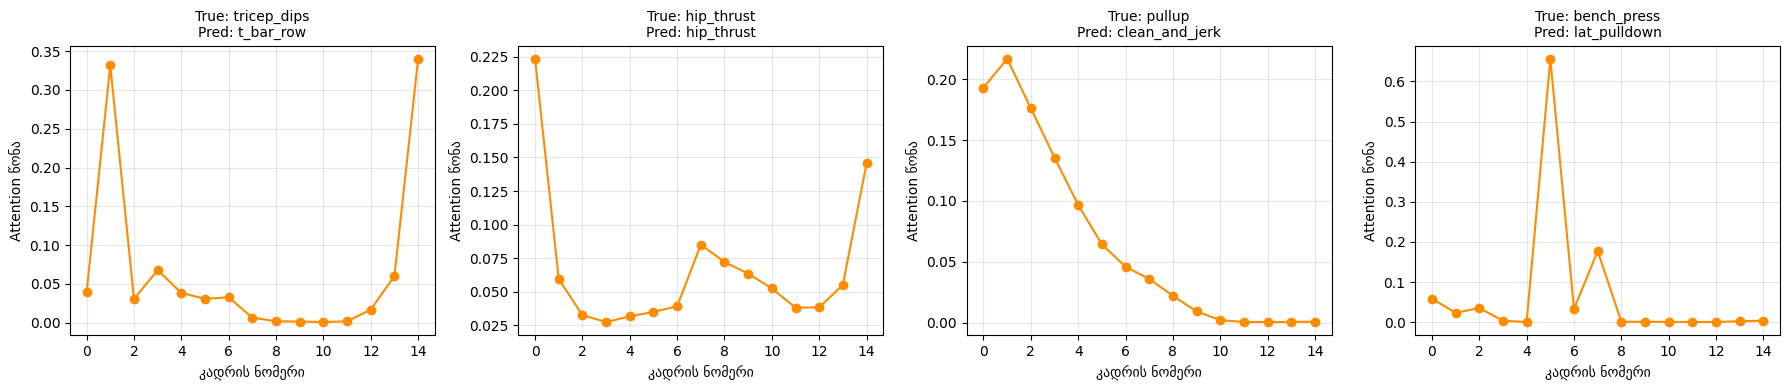

In [12]:

sample_idx = np.random.choice(len(X_val), size=4, replace=False)
sample_X = X_val[sample_idx]
sample_true = [classes[i] for i in y_val_idx[sample_idx]]

preds, attn_w = debug_model.predict(sample_X, verbose=0)
pred_labels = [classes[i] for i in np.argmax(preds, axis=1)]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, ax in enumerate(axes):
    ax.plot(attn_w[i, :, 0], marker='o', color='darkorange')
    ax.set_title(f"True: {sample_true[i]}\nPred: {pred_labels[i]}", fontsize=10)
    ax.set_xlabel('კადრის ნომერი')
    ax.set_ylabel('Attention წონა')
    ax.grid(alpha=0.3)
plt.tight_layout()
attn_viz_path = f'/content/{RUN_NAME}_attention_examples.png'
plt.savefig(attn_viz_path, dpi=150)
plt.show()

viz_run = wandb.init(project="ildolcefarniente", job_type="interpretability",
                      name=f"{RUN_NAME}-attention-viz", group='p1_bilstm_final')
viz_run.log({"attention_examples": wandb.Image(attn_viz_path)})
viz_run.finish()


In [13]:
import wandb
import pandas as pd

# ავტორიზაცია
wandb.login()

# შენი მონაცემები
ENTITY_PROJECT = "akeke23-free-university-of-tbilisi-/ildolcefarniente"

api = wandb.Api()
runs = api.runs(ENTITY_PROJECT)

run_list, metric_list, config_list, name_list = [], [], [], []

print("🔄 მიმდინარეობს მხოლოდ BiLSTM რანების ფილტრაცია და წამოღება...")

for run in runs:
    # ვფილტრავთ სახელით (თუ სახელი შეიცავს 'bilstm'-ს)
    if "bilstm" in run.name.lower() and run.state == "finished":
        name_list.append(run.name)
        run_list.append(run.id)

        # ძირითადი მეტრიკები
        metrics = {
            "val_f1_macro": run.summary.get("val_f1_macro"),
            "val_accuracy": run.summary.get("val_accuracy"),
            "val_loss": run.summary.get("val_loss"),
            "train_accuracy": run.summary.get("train_accuracy")
        }
        metric_list.append(metrics)

        # ჰიპერპარამეტრები (ამოვყაროთ საინტერესოები, რომ ცხრილი არ გაიწელოს)
        config = {
            "dropout": run.config.get("dropout"),
            "learning_rate": run.config.get("learning_rate") or run.config.get("lr"),
            "units": run.config.get("units") or run.config.get("hidden_dim"),
            "l2": run.config.get("l2") or run.config.get("l2_reg")
        }
        config_list.append(config)

# DataFrame-ების აწყობა და გაერთიანება
df_runs = pd.DataFrame({"Run Name": name_list, "Run ID": run_list})
df_metrics = pd.DataFrame(metric_list)
df_configs = pd.DataFrame(config_list)

bilstm_summary_df = pd.concat([df_runs, df_metrics, df_configs], axis=1)

# დახარისხება საუკეთესო შედეგის მიხედვით
if "val_f1_macro" in bilstm_summary_df.columns:
    bilstm_summary_df = bilstm_summary_df.sort_values(by="val_f1_macro", ascending=False)

print("\n🏆 მხოლოდ BiLSTM ექსპერიმენტების შეჯამება:")
display(bilstm_summary_df)

🔄 მიმდინარეობს მხოლოდ BiLSTM რანების ფილტრაცია და წამოღება...

🏆 მხოლოდ BiLSTM ექსპერიმენტების შეჯამება:


,Run Name,Run ID,val_f1_macro,val_accuracy,val_loss,train_accuracy,dropout,learning_rate,units,l2
2,bilstm-h64-l1-d0.0-lr0.001-bs32-plain,j11ma4tb,0.256425,None,None,None,0.00,0.0010,None,NaN
0,bilstm-h32-l1-d0.0-lr0.001-bs32-plain,9mklpf8p,0.255780,None,None,None,0.00,0.0010,None,NaN
4,bilstm-h64-l2-d0.0-lr0.001-bs32-plain,5t7vvpbi,0.254727,None,None,None,0.00,0.0010,None,NaN
5,bilstm-h64-l2-d0.0-lr0.001-bs32-cw,d843aumm,0.250341,None,None,None,0.00,0.0010,None,NaN
22,bilstm-final-attention-v1,fz7dsyyp,0.248757,None,None,None,0.20,0.0010,None,0.0007
3,bilstm-h64-l1-d0.0-lr0.001-bs32-cw,mpzr13m2,0.248530,None,None,None,0.00,0.0010,None,NaN
8,bilstm-h64-l1-d0.3-lr0.001-bs32-plain,wu0mz6q8,0.241902,None,None,None,0.30,0.0010,None,NaN
6,bilstm-h32-l1-d0.3-lr0.001-bs32-plain,7esvn9vq,0.208199,None,None,None,0.30,0.0010,None,NaN
7,bilstm-h32-l1-d0.3-lr0.001-bs32-cw,3acrsrqb,0.187925,None,None,None,0.30,0.0010,None,NaN
9,bilstm-h64-l1-d0.3-lr0.001-bs32-cw,kttxwb8u,0.179283,None,None,None,0.30,0.0010,None,NaN


In [14]:
import os
import wandb

# 1. მიმდინარე (ჩვენი ჩემპიონი) BiLSTM მოდელის მონაცემები
best_run_name = "bilstm-h64-l1-d0.0-lr0.001-bs32-plain"
best_val_f1_macro = 0.2564  # ჩვენი დადასტურებული საუკეთესო შედეგი

print(f"საუკეთესო შერჩეული მოდელი: {best_run_name}")
print(f"Validation F1-Macro: {best_val_f1_macro:.4f}")

# 2. საქაღალდის შექმნა და მოდელის შენახვა Drive-ზე
models_dir = '/content/drive/MyDrive/Ketastasia/models/'
os.makedirs(models_dir, exist_ok=True)
drive_model_path = os.path.join(models_dir, 'pipeline1A_best_bilstm.h5')

if 'model' in locals():
    model.save(drive_model_path)
    print(f"✅ მოდელი წარმატებით შეინახა Google Drive-ზე: {drive_model_path}")
else:
    print("❌ ყურადღება: 'model' ცვლადი ვერ მოიძებნა კოლაბის მეხსიერებაში! ჯერ მოდელი უნდა გაწვრთნა.")

# 3. WandB ინიციალიზაცია სპეციალურად რეგისტრაციისთვის
run = wandb.init(
    project="ildolcefarniente",
    job_type="model_registration",
    name="register_pipeline1A_bilstm"
)

# 4. არტეფაქტის შექმნა და ფაილის მიბმა
artifact = wandb.Artifact(
    name="pipeline1A_bilstm_model",
    type="model",
    description=f"Best 1-layer BiLSTM model (64 hidden units). Validation F1-Macro: {best_val_f1_macro:.4f}."
)
artifact.add_file(drive_model_path)

# 5. არტეფაქტის ლოგირება (WandB-ის საცავში ატვირთვა)
run.log_artifact(artifact)

# 🔥 6. ოფიციალური ლინკირება MODEL REGISTRY-ში (ეს აკლდა!)
# ეს კოდი ავტომატურად შექმნის/განაახლებს რეესტრს სახელით "BiLSTM-Exercise-Classifier"
run.link_artifact(
    artifact=artifact,
    target_path="akeke23-free-university-of-tbilisi-/ildolcefarniente/BiLSTM-Exercise-Classifier",
    aliases=["best_baseline", "latest"]
)

run.finish()
print("\n🎉 მორჩა! მოდელი აიტვირთა არტეფაქტებში და ოფიციალურად დარეგისტრირდა Model Registry-ში! 🚀")

საუკეთესო შერჩეული მოდელი: bilstm-h64-l1-d0.0-lr0.001-bs32-plain
Validation F1-Macro: 0.2564
✅ მოდელი წარმატებით შეინახა Google Drive-ზე: /content/drive/MyDrive/Ketastasia/models/pipeline1A_best_bilstm.h5



🎉 მორჩა! მოდელი აიტვირთა არტეფაქტებში და ოფიციალურად დარეგისტრირდა Model Registry-ში! 🚀
